In [238]:
import os

import numpy as np
import pandas as pd
from features import *
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [239]:
def complete_dict(list_dataframe, cleaness):
    if cleaness == 0:
        path = "../Data/train/with_label/clean"
    elif cleaness == 1:
        path = "../Data/train/with_label/dirty"
    else:
        path = "../Data/train/with_label/very_dirty"
    for e in os.scandir(path):
        if e.is_file():
            dict = {}
            path = e.path
            dict['name'] = e.name
            features_img = extract_features(path)
            for key in features_img.keys():
                dict[key] = features_img[key]
            if cleaness == 0 :
                dict['class'] = 'clean'
            elif cleaness == 1:
                dict['class'] = 'dirty'
            else:
                dict['class'] = 'very_dirty'
            list_dataframe.append(dict)

In [240]:
def get_dataframe() -> list:
    list_dataframe = []

    complete_dict(list_dataframe, 0)    
    complete_dict(list_dataframe, 1)
    complete_dict(list_dataframe, 2)

    return list_dataframe

In [241]:
list_df = get_dataframe()
df = pd.DataFrame(list_df)
df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']] = df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']].astype(float)
df[['image_width', 'image_height', 'contraste_maximal']] = df[['image_width', 'image_height', 'contraste_maximal']].astype(int)

In [242]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,saturation,hist_rgb,hist_luminance,edge_density,edge_density_V2,class
0,train_clean_img_000.jpeg,1.30,349,352,32.00,32.00,32.00,32.00000,0,0.000000,0.00,"{""red"": [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.0014,0.0,clean
1,train_clean_img_001.jpeg,69.07,600,600,122.38,127.30,121.96,125.22016,255,56.431390,29.34,"{""red"": [112, 31, 25, 24, 34, 37, 61, 53, 72, ...","[2, 30, 30, 16, 20, 21, 28, 35, 35, 45, 43, 59...",0.1123,52896.0,clean
2,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,52.834800,35.23,"{""red"": [6, 4, 3, 5, 4, 10, 12, 29, 29, 36, 59...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,23008.0,clean
3,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,39.285711,44.90,"{""red"": [51, 22, 23, 32, 45, 34, 56, 50, 66, 5...","[4, 11, 10, 19, 36, 33, 41, 48, 59, 75, 61, 67...",0.0541,52980.0,clean
4,train_clean_img_004.jpeg,47.19,600,600,130.68,132.26,129.66,131.49118,254,44.082522,17.39,"{""red"": [8, 2, 7, 10, 6, 4, 13, 16, 24, 27, 26...","[0, 4, 1, 5, 2, 2, 10, 13, 15, 20, 22, 30, 41,...",0.0677,37542.0,clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,train_no_label_img_512.jpeg,276.22,600,338,133.58,128.67,120.25,129.17821,255,70.702186,65.50,"{""red"": [61, 26, 27, 20, 32, 55, 65, 105, 167,...","[4, 2, 4, 8, 12, 16, 34, 65, 138, 164, 225, 26...",0.1471,41776.0,very_dirty
153,train_no_label_img_515.jpeg,276.22,600,338,133.58,128.67,120.25,129.17821,255,70.702186,65.50,"{""red"": [61, 26, 27, 20, 32, 55, 65, 105, 167,...","[4, 2, 4, 8, 12, 16, 34, 65, 138, 164, 225, 26...",0.1471,41776.0,very_dirty
154,train_no_label_img_517.jpeg,1547.53,1920,2560,81.42,85.96,76.49,83.52296,253,52.977069,57.30,"{""red"": [58, 35, 85, 202, 727, 2739, 9087, 200...","[0, 0, 1, 2, 72, 1151, 6848, 17708, 25976, 258...",0.0186,111346.0,very_dirty
155,train_no_label_img_521.jpeg,31.21,600,345,112.12,107.95,101.57,108.46951,254,56.065589,42.87,"{""red"": [35, 38, 59, 113, 147, 274, 366, 504, ...","[12, 31, 43, 89, 140, 248, 378, 494, 634, 714,...",0.0440,28214.0,very_dirty


Get the max and min of every color of the histogramme

In [243]:
df['max_r'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['max_g'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['max_b'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

df['min_r'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['min_g'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['min_b'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

Get index of max

In [244]:
df['index_max_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['max_r']), axis =1)
df['index_max_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['max_g']), axis =1)
df['index_max_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['max_b']), axis =1)

df['index_min_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['min_r']), axis =1)
df['index_min_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['min_g']), axis =1)
df['index_min_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['min_b']), axis =1)

Get the max and min of the luminance

In [245]:
df['max_lum'] = df.apply(lambda row : max(ast.literal_eval(row['hist_luminance'])), axis =1)
df['min_lum'] = df.apply(lambda row : min(ast.literal_eval(row['hist_luminance'])), axis =1)

In [246]:
df['index_max_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['max_lum']), axis =1)
df['index_min_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['min_lum']), axis =1)

Get the difference and sum of the averages

In [247]:
df['sum_avg'] = df['mean_r'] + df['mean_g'] + df['mean_b']
df['sum_diff_avg'] = abs(df['mean_r'] - df['mean_g']) + abs(df['mean_r'] - df['mean_b']) + abs(df['mean_b'] - df['mean_g'])

In [248]:
def get_whites_from_hist_v2(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])

    diff =abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum(((mean - diff)>0)[200:])
    return whites

In [249]:
def get_whites_from_hist(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])
    diff = abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum(((mean - diff)>0))
    print(whites)
    return whites


get_whites_from_hist_v2(ast.literal_eval(df.iloc[2]['hist_rgb']))

np.int64(48)

In [250]:
df['quantity_of_whites'] = df.apply(lambda row : get_whites_from_hist(ast.literal_eval(row['hist_rgb'])), axis =1)
#df['quantity of whites'] = df.apply(lambda row : get_whites_from_hist_v2(ast.literal_eval(row['hist_rgb'])), axis =1)


1
201
122
56
211
74
148
203
177
189
115
122
132
166
99
116
95
172
41
141
150
196
127
120
70
123
73
130
49
174
207
86
139
129
92
93
91
68
164
112
177
120
124
122
176
169
95
178
129
151
155
121
198
153
152
176
125
207
103
136
52
174
156
165
115
118
108
190
113
152
212
74
227
144
101
135
222
189
134
215
211
185
116
238
123
97
155
183
63
87
193
178
22
157
95
76
63
168
10
5
85
88
121
145
87
53
141
42
84
64
130
110
168
85
246
207
185
146
179
240
230
101
151
130
235
185
120
199
190
183
140
129
119
135
215
224
230
110
251
164
211
178
211
215
246
185
219
193
199
146
225
188
130
130
168
185
130


In [251]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [252]:
df.head(20)

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,...,index_min_r,index_min_g,index_min_b,max_lum,min_lum,index_max_lum,index_min_lum,sum_avg,sum_diff_avg,quantity_of_whites
0,train_clean_img_000.jpeg,1.30,349,352,32.00,32.00,32.00,32.00000,0,0.000000,...,0,0,0,122848,0,32,0,96.00,0.00,1
1,train_clean_img_001.jpeg,69.07,600,600,122.38,127.30,121.96,125.22016,255,56.431390,...,253,0,1,9653,2,119,0,371.64,10.68,201
2,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,52.834800,...,2,1,1,6058,0,255,0,325.82,18.18,122
3,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,39.285711,...,241,242,247,5644,1,147,233,364.24,4.84,56
4,train_clean_img_004.jpeg,47.19,600,600,130.68,132.26,129.66,131.49118,254,44.082522,...,1,1,254,10928,0,192,0,392.60,5.20,211
5,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.32,109.33151,255,48.527985,...,1,1,1,39961,11,80,0,322.49,19.90,74
6,train_clean_img_006.jpeg,71.17,600,600,112.90,117.21,106.13,114.65819,255,51.106774,...,244,251,252,5464,4,131,250,336.24,22.16,148
7,train_clean_img_007.jpeg,60.29,600,600,112.64,114.69,108.39,113.35885,255,52.025121,...,253,249,254,5505,7,124,252,335.72,12.60,203
8,train_clean_img_008.jpeg,68.59,600,600,117.65,117.13,116.23,117.18288,255,49.744273,...,2,250,254,4129,2,104,0,351.01,2.84,177
9,train_clean_img_009.jpeg,71.62,600,600,114.25,113.72,109.11,113.35293,255,49.018398,...,1,1,1,6264,2,107,0,337.08,10.28,189


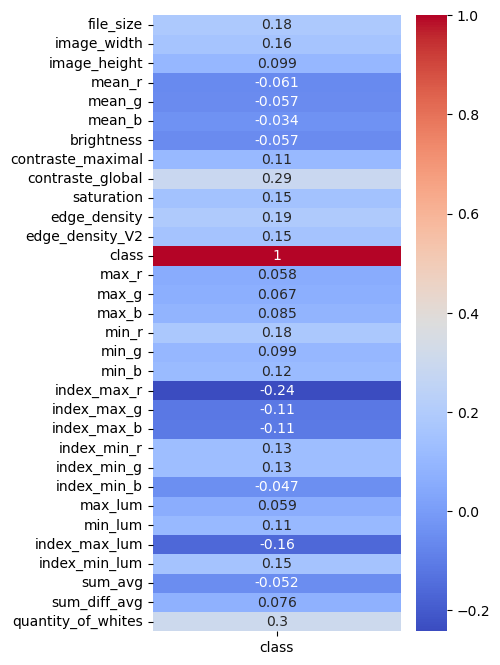

In [253]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(4, 8))
sns.heatmap(corr_matrix[['class']], cmap='coolwarm', annot = True)
plt.show()

We tested the correlation matrix with the initial 40 images and the correlation matrix with additional images classified by hand (132 images in total)

Test with 20 images from each side, we keep >0.15 and <-0.15
- file_size
- image_width
- image_height
- mean_r
- mean_g
- brightness
- contraste_global
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_avg
- quantities_of_whites

test with 66 images from each side, we keep >0.1 and <0.1
- file_size
- image_width
- image_height
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- index_min_b
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_diff_avg

We can see that some values are still here and some changed. We will do some tests and check if some values should not be kept. In the mean time, we will keep the variables from the test with the biggest number

In [254]:
df_clean = df[df['class'] == 0]
df_dirty = df[df['class'] == 1]

In [ ]:
weights = {"mean_r":0, "mean_g":0, "brightness":0, "contraste_global":0.42, "edge_density_V2":0.3, "max_r":0, "max_g":0, "max_b":0, "min_r":0.55, "min_g":0, "min_b":0.45, "index_max_r":0, "index_max_g":0, "max_lum":0, "min_lum":0.33, "index_max_lum":0, "index_min_lum":0, "sum_avg":0, "quantity_of_whites":0.49}

def score_to_class(score):
    if score < 50:
        clean_class = "clean"
    elif 50 <= score <= 75:
        clean_class = "dirty"
    else:
        clean_class = "very_dirty"
    return clean_class

def compute_score(img_features):
    cleaness_score = sum([img_features[k]*v for k,v in weights.items()])
    return cleaness_score
#print(df.iloc[1])
print(compute_score(df.iloc[1]))